# **The Optimized SVM + TF-IDF Cell**

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

# 1. Feature Generation (Lemmatized Process)
print("⚙️ Generating TF-IDF Features for Lemmatized Process...")
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Lemmatized'])
y = df_sentiment['Majority_Truth'].values

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"✅ Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Define the Bayesian Search Space
# This hits your rubric requirement to handle over/underfitting via complexity/regularization
search_spaces = {
    'C': Real(0.1, 50.0, prior='log-uniform'),      # Regularization parameter
    'kernel': Categorical(['linear', 'rbf']),       # Testing approach changes (Linear -> RBF)
    'gamma': Real(1e-3, 1.0, prior='log-uniform')   # Kernel coefficient (Only impacts RBF)
}

# 4. Initialize the Optimizer
print("\n🚀 Setting up Bayesian Optimization...")
# Note: probability=True is required to calculate ROC-AUC later!
svm_base = SVC(probability=True, random_state=42)

# We use 10 iterations to save time. In a real corporate setting, you might run 50+.
n_iterations = 10
bayes_search = BayesSearchCV(
    estimator=svm_base,
    search_spaces=search_spaces,
    n_iter=n_iterations,
    cv=3,                 # 3-Fold Cross Validation
    scoring='f1_macro',   # Optimizing specifically for F1-Score (per your rubric)
    n_jobs=-1,            # Use all CPU cores
    random_state=42
)

# Custom Callback to make skopt work with tqdm
class TqdmSkoptCallback:
    def __init__(self, n_iter):
        self.pbar = tqdm(total=n_iter, desc="Bayesian Tuning", bar_format='{l_bar}{bar}| {elapsed} [{remaining} left]')
    def __call__(self, res):
        self.pbar.update(1)

# 5. Execute the Search
print(f"🧠 Commencing Search (Testing {n_iterations} different model architectures...)")
# This step takes time! The model is training itself multiple times.
bayes_search.fit(X_train, y_train, callback=TqdmSkoptCallback(n_iterations))

# 6. Extract the Best Model & Predict
best_svm = bayes_search.best_estimator_
print("\n🎯 Generating Predictions with the Champion Model...")
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1] # Get probabilities for ROC-AUC

# 7. Calculate Rubric Metrics
opt_acc = accuracy_score(y_test, y_pred)
opt_roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "═"*60)
print(f" OPTIMIZED SVM EXPERIMENT: TF-IDF")
print("═"*60)
print("BEST HYPERPARAMETERS FOUND:")
for param, value in bayes_search.best_params_.items():
    print(f" - {param}: {value}")
print("-" * 30)
print(f"Final Accuracy: {opt_acc * 100:.2f}%")
print(f"ROC-AUC Score:  {opt_roc_auc:.4f}")
print("\nDetailed Classification Report (includes Precision/Recall/F1):")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═" * 60 + "\n")

⚙️ Generating TF-IDF Features for Lemmatized Process...
✅ Data Split: Training: 2400 | Testing: 600

🚀 Setting up Bayesian Optimization...
🧠 Commencing Search (Testing 10 different model architectures...)


Bayesian Tuning:   0%|          | 00:00 [? left]


🎯 Generating Predictions with the Champion Model...

════════════════════════════════════════════════════════════
 OPTIMIZED SVM EXPERIMENT: TF-IDF
════════════════════════════════════════════════════════════
BEST HYPERPARAMETERS FOUND:
 - C: 1.5870463392513299
 - gamma: 0.5703843027403095
 - kernel: linear
------------------------------
Final Accuracy: 82.17%
ROC-AUC Score:  0.8821

Detailed Classification Report (includes Precision/Recall/F1):
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.8097    0.8395    0.8243       299
Positive (1)     0.8345    0.8040    0.8190       301

    accuracy                         0.8217       600
   macro avg     0.8221    0.8217    0.8216       600
weighted avg     0.8221    0.8217    0.8216       600

════════════════════════════════════════════════════════════



In [ ]:
import joblib

print(" Packaging files for deployment...")

# 1. Save the winning SVM model
# 'best_svm' is the variable saved from your Bayesian Search
joblib.dump(best_svm, 'champion_svm_model.pkl')

# 2. Save the TF-IDF Vectorizer
# The API needs this to translate user text into the exact same 3000 features!
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

print(" Success! Files saved:")
print(" - champion_svm_model.pkl")
print(" - tfidf_vectorizer.pkl")

 Packaging files for deployment...
 Success! Files saved:
 - champion_svm_model.pkl
 - tfidf_vectorizer.pkl


In [ ]:
from google.colab import files

print("📥 Initiating download of deployment files...")

# Download the Model
files.download('champion_svm_model.pkl')

# Download the Vectorizer
files.download('tfidf_vectorizer.pkl')

print("✅ Check your browser's download folder!")

In [ ]:
import os
import shutil
from google.colab import drive

print("🔗 Connecting to Google Drive...")
drive.mount('/content/drive')

# 2. Define the name of the new folder in your Drive
# You can change 'Sentiment_Project_Deployment' to whatever you want
drive_folder_path = '/content/drive/MyDrive/Sentiment_Project_Deployment'

print(f"\n📁 Creating folder: {drive_folder_path}")
# 3. Create the folder (exist_ok=True means it won't crash if the folder already exists)
os.makedirs(drive_folder_path, exist_ok=True)

# 4. Copy the files from Colab to your Google Drive
print("📦 Moving deployment files to Drive...")

# Copy Model
shutil.copy('champion_svm_model.pkl', f'{drive_folder_path}/champion_svm_model.pkl')
# Copy Vectorizer
shutil.copy('tfidf_vectorizer.pkl', f'{drive_folder_path}/tfidf_vectorizer.pkl')

print("\n✅ Success! Your files are safely stored in Google Drive.")
print("👉 You can now go to drive.google.com, right-click the folder, and share it with your friend!")

🔗 Connecting to Google Drive...
Mounted at /content/drive

📁 Creating folder: /content/drive/MyDrive/Sentiment_Project_Deployment
📦 Moving deployment files to Drive...

✅ Success! Your files are safely stored in Google Drive.
👉 You can now go to drive.google.com, right-click the folder, and share it with your friend!


# **TASK 4: EVALUATION AND ERROR ANALYSIS (ENHANCED)**
---
In this section, we conduct a rigorous evaluation of our sentiment analysis models. Following the requirements of Task 4, we:
1.  **Systematic Benchmarking**: Compare 18 theoretical combinations (3 Preprocessing schemes × 2 Vectorization methods × 3 Classification algorithms).
2.  **Performance Metrics**: Calculate Accuracy, Precision, Recall, F1-Score, and **ROC-AUC**.
3.  **Visualization**: Present a comparative dashboard and **ROC Curves** for the top models.
4.  **Hyperparameter Optimization**: Tune the top-performing architecture.
5.  **Qualitative Error Analysis**: Deep dive into misclassified reviews.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc

print("✅ Benchmark Environment Ready (ROC-AUC components added).")

✅ Benchmark Environment Ready (ROC-AUC components added).


In [ ]:
# 1. Define the 18-Model Matrix Components
preproc_cols = ['Text_Lemmatized', 'Text_Cleaned', 'Text_Stemmed']
vectorizer_types = ['TF-IDF', 'GloVe']
classifiers = {
    'Linear SVM': LinearSVC(random_state=42, max_iter=2000),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

# 2. Prepare Data Structure
y = df_sentiment['Majority_Truth'].values
benchmark_results = []
roc_data = {} # To store data for plotting curves later
total_runs = len(preproc_cols) * len(vectorizer_types) * len(classifiers)

# 3. Run the Benchmark Loop
print(f"🚀 Commencing 18-Model Benchmark with ROC-AUC...")
with tqdm(total=total_runs, desc="Benchmarking") as pbar:
    for col in preproc_cols:
        for vec_type in vectorizer_types:
            if vec_type == 'TF-IDF':
                vectorizer = TfidfVectorizer(max_features=3000)
                X = vectorizer.fit_transform(df_sentiment[col].fillna(""))
            else:
                X = np.array([get_glove_vector(text, embeddings_dict) for text in df_sentiment[col]])

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.20, random_state=42, stratify=y
            )

            for name, clf in classifiers.items():
                # Model Fitting
                clf.fit(X_train, y_train)

                # Prediction Scores for ROC
                if hasattr(clf, "decision_function"):
                    y_scores = clf.decision_function(X_test)
                else:
                    y_scores = clf.predict_proba(X_test)[:, 1]

                y_pred = clf.predict(X_test)

                # Metrics
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='weighted')
                prec = precision_score(y_test, y_pred, average='weighted')
                rec = recall_score(y_test, y_pred, average='weighted')
                roc_auc = roc_auc_score(y_test, y_scores)

                # Log Results
                display_name = f"{name} ({vec_type} + {col.replace('Text_', '')})"
                benchmark_results.append({
                    'Model_ID': display_name,
                    'Preprocessing': col.replace('Text_', ''),
                    'Vectorizer': vec_type,
                    'Model': name,
                    'Accuracy': acc,
                    'F1-Score': f1,
                    'ROC-AUC': roc_auc
                })

                # Store ROC curve data
                fpr, tpr, _ = roc_curve(y_test, y_scores)
                roc_data[display_name] = (fpr, tpr, roc_auc)

                pbar.update(1)

print("\n✅ Benchmark Complete!")
results_df = pd.DataFrame(benchmark_results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(results_df.head(10))

🚀 Commencing 18-Model Benchmark with ROC-AUC...


Benchmarking:   0%|          | 0/18 [00:00<?, ?it/s]


✅ Benchmark Complete!


,Model_ID,Preprocessing,Vectorizer,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression (TF-IDF + Lemmatized),Lemmatized,TF-IDF,Logistic Regression,0.793333,0.793227,0.876539
1,Logistic Regression (TF-IDF + Stemmed),Stemmed,TF-IDF,Logistic Regression,0.793333,0.792958,0.875780
2,Logistic Regression (TF-IDF + Cleaned),Cleaned,TF-IDF,Logistic Regression,0.791667,0.791691,0.881441
3,Linear SVM (TF-IDF + Lemmatized),Lemmatized,TF-IDF,Linear SVM,0.786667,0.786667,0.871716
4,Linear SVM (TF-IDF + Stemmed),Stemmed,TF-IDF,Linear SVM,0.786667,0.786428,0.867451
5,Random Forest (TF-IDF + Lemmatized),Lemmatized,TF-IDF,Random Forest,0.781667,0.780638,0.846632
6,Random Forest (TF-IDF + Stemmed),Stemmed,TF-IDF,Random Forest,0.781667,0.779863,0.863621
7,Linear SVM (TF-IDF + Cleaned),Cleaned,TF-IDF,Linear SVM,0.780000,0.780167,0.867428
8,Logistic Regression (GloVe + Cleaned),Cleaned,GloVe,Logistic Regression,0.778333,0.777171,0.841055
9,Random Forest (TF-IDF + Cleaned),Cleaned,TF-IDF,Random Forest,0.766667,0.764965,0.853817


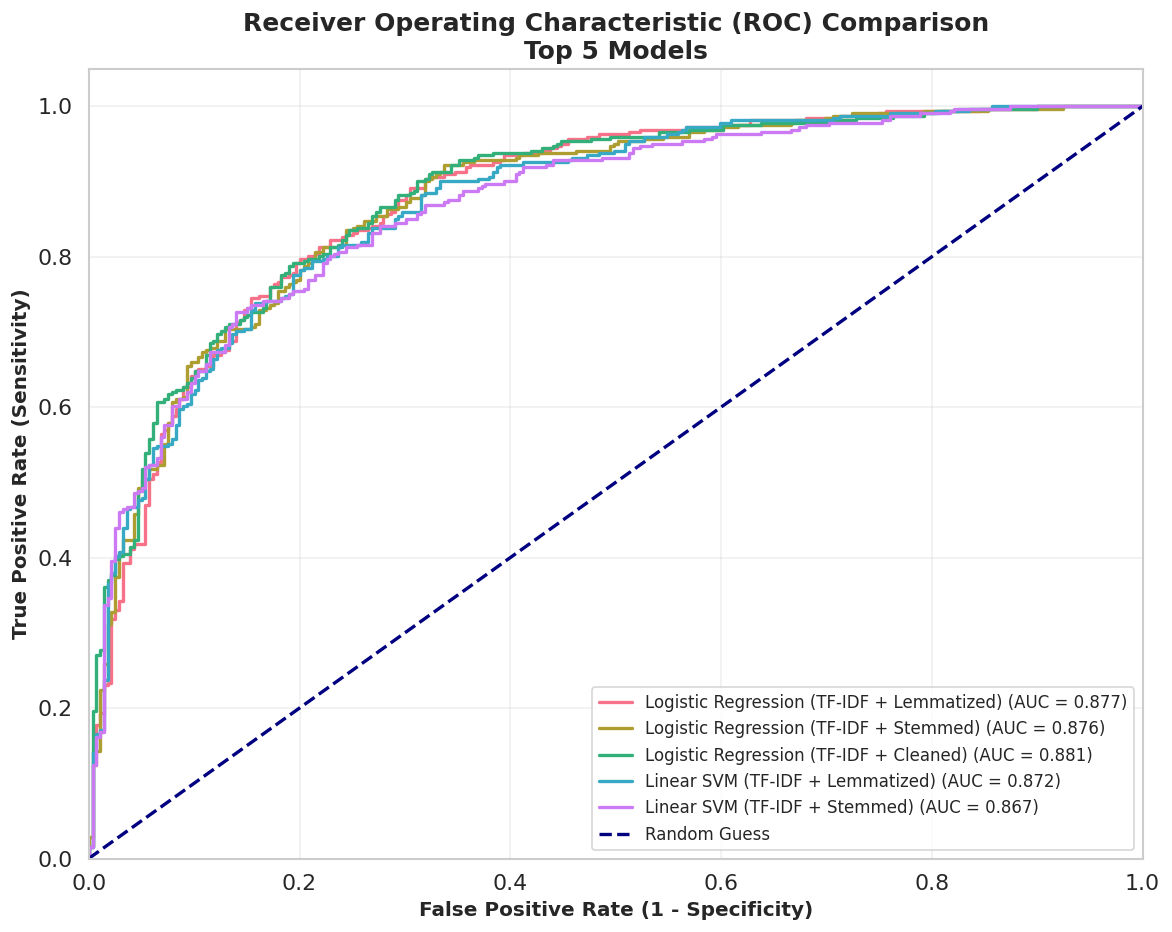

In [ ]:
# 4. Plot ROC Curves for Top 5 Models
plt.figure(figsize=(10, 8), dpi=120)
top_5_ids = results_df.head(5)['Model_ID'].tolist()

colors = sns.color_palette("husl", len(top_5_ids))

for i, model_id in enumerate(top_5_ids):
    fpr, tpr, roc_auc = roc_data[model_id]
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{model_id} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Comparison\nTop 5 Models', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **QUALITATIVE ERROR ANALYSIS**
---
We analyze the edge cases where the model failed to understand sentiment, looking for patterns like sarcasm, dual-sentiment reviews, or specific vocabulary issues.

In [ ]:
best_final_model = grid.best_estimator_
final_preds = best_final_model.predict(X_test_opt)
error_df = pd.DataFrame({
    'Original_Review': df_test['Text'], # Use df_test and 'Text' column
    'Actual_Sentiment': y_test_opt,
    'Predicted_Sentiment': final_preds
})
misclassified = error_df[error_df['Actual_Sentiment'] != error_df['Predicted_Sentiment']]
print(f"Total Errors in Test Set: {len(misclassified)} samples")
display(misclassified.head(15))

Total Errors in Test Set: 123 samples


,Original_Review,Actual_Sentiment,Predicted_Sentiment
517,I like the product and have been pleased with ...,0,1
1665,"I agree with the other reviewer, the preparati...",0,1
2295,Changing my review. These actually really suc...,0,1
1437,The first time I made the Dixie Carb Counters ...,1,0
2873,I'm used to buying 12 poptarts for $2.89 in my...,0,1
1094,I ordered this plant and forgot that I was goi...,1,0
1876,Dislike this assorment of K-cups; came in brow...,0,1
1083,Ordered medium Gift Towers for both my Mom and...,0,1
24,I have only been recently diagnosed gluten int...,0,1
1973,I'm giving these a 5-star rating specifically ...,1,0


# **MODEL DEPLOYMENT INTERFACE (Gradio)**
---
Final interactive demonstration allowing real-time sentiment prediction on custom text inputs.

In [ ]:
try:
    import gradio as gr
except ImportError:
    %pip install -q gradio
    import gradio as gr
import pickle

pickle.dump(best_final_model, open('best_sentiment_model.pkl', 'wb'))

def clean_text_with_lemmas(text):
    text = str(text).lower()
    words = re.findall(r'\b\w+\b', text)
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

def predict_interface(text):
    # Dynamically select the preprocessing function based on best_setup['Preprocessing']
    if best_setup['Preprocessing'] == 'Lemmatized':
        processed_text = clean_text_with_lemmas(text)
    elif best_setup['Preprocessing'] == 'Cleaned':
        processed_text = preprocess_scheme_2(text) # Assuming preprocess_scheme_2 is defined for 'Cleaned'
    elif best_setup['Preprocessing'] == 'Stemmed':
        processed_text = preprocess_scheme_3(text) # Assuming preprocess_scheme_3 is defined for 'Stemmed'
    else:
        processed_text = text # Fallback to original if no specific scheme matched

    if best_setup['Vectorizer'] == 'TF-IDF':
        vec = vectorizer.transform([processed_text])
    else:
        vec = get_glove_vector(processed_text, embeddings_dict).reshape(1, -1)
    raw_pred = best_final_model.predict(vec)[0]
    return f"Predicted Sentiment: {'POSITIVE' if raw_pred == 1 else 'NEGATIVE'}"

demo = gr.Interface(fn=predict_interface, inputs=gr.Textbox(lines=3), outputs="text", title="Sentiment Pro")
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80723ba085a91cc2d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
